In [1]:
import numpy as np
# Magics
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Resets to standard white background
import seaborn as sns
sns.set_theme()
sns.set_style('ticks')
sns.set_context('talk')
from ephys.decoder import *

Processing session 1/13: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/13: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/13: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/13: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/13: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/13: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/13: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/13: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/13: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/13: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/13: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/13: 007_2024-07-11_12-39-21...
Files exist in folder

# Load data

## Load spike counts

In [50]:
subject = '007'
folder_parent = Path.home() / 'data' / subject

ephys_ids = [
    '007_2024-06-22_10-48-57',
    '007_2024-06-23_12-46-55',
    '007_2024-06-24_17-47-22',
    '007_2024-06-25_15-54-23',
    '007_2024-06-26_15-19-30',
    '007_2024-06-27_15-06-28',
    '007_2024-06-28_14-18-51',
    '007_2024-06-29_16-24-52',
    # '007_2024-07-06_11-16-25',  # Bad session
    # '007_2024-07-07_13-20-29',  # Bad session
    '007_2024-07-08_12-20-29',
    '007_2024-07-09_12-10-57',
    '007_2024-07-10_12-03-35',
    '007_2024-07-11_12-39-21',
    # '007_2024-07-12_13-29-26'  # ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1.
                                 # This happens because in correct disengaged trials the animal only responded right, so there's no left trials in labels
]

# Load spike counts for all neurons of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Get spike counts
    if any(f.endswith('.npy') for f in os.listdir(folder_child)):
        print('Files exist in folder. Skipping')
        continue
    else:
        print('Files do not exist in folder. Proceeding')
        df_ttl, df_behavior, n_trials, df_spikes, cluster_info, x, height, labels, y, width, left, ts_edges, events_edges = \
            preprocess(ephys_ids[i])
        bins, all_psth = get_all_psth(cluster_info, df_spikes, df_ttl, n_trials, time_win=[-1, 3], bin_size=0.1)
    # Save bins and psth
    np.save(folder_child / 'bins.npy', bins)
    np.save(folder_child / 'all_psth.npy', all_psth)

Processing session 1/12: 007_2024-06-22_10-48-57...
Files exist in folder. Skipping
Processing session 2/12: 007_2024-06-23_12-46-55...
Files exist in folder. Skipping
Processing session 3/12: 007_2024-06-24_17-47-22...
Files exist in folder. Skipping
Processing session 4/12: 007_2024-06-25_15-54-23...
Files exist in folder. Skipping
Processing session 5/12: 007_2024-06-26_15-19-30...
Files exist in folder. Skipping
Processing session 6/12: 007_2024-06-27_15-06-28...
Files exist in folder. Skipping
Processing session 7/12: 007_2024-06-28_14-18-51...
Files exist in folder. Skipping
Processing session 8/12: 007_2024-06-29_16-24-52...
Files exist in folder. Skipping
Processing session 9/12: 007_2024-07-08_12-20-29...
Files exist in folder. Skipping
Processing session 10/12: 007_2024-07-09_12-10-57...
Files exist in folder. Skipping
Processing session 11/12: 007_2024-07-10_12-03-35...
Files exist in folder. Skipping
Processing session 12/12: 007_2024-07-11_12-39-21...
Files exist in folder

## Load behavior

In [51]:
# Load behavior of a session (bins, all_psth). If file doesn't exist, create it
for i in range(len(ephys_ids)):

    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    print(f'Parsing behavioral session {i + 1}/{len(ephys_ids)}: {filename[:-4]}...')

    # Create child folder within parent folder for each ephys_id with its name if it doesn't exist
    folder_child = folder_parent / ephys_ids[i]
    folder_child.mkdir(parents=True, exist_ok=True)
    os.chdir(folder_child)

    # Execute only if folder is empty
    if any(f.endswith('.csv') for f in os.listdir(folder_child)):
        print('File exist in folder. Skipping')
        continue
    else:
        print('File does not exist in folder. Proceeding')
        df_behavior = parse_v2(path_behavior)
        df_behavior.to_csv(folder_child / filename, index=False)


behavior = []
for i in range(len(ephys_ids)):
    path_behavior = get_behavior_id(ephys_ids[i])
    filename = path_behavior.name
    folder_child = folder_parent / ephys_ids[i]
    df = pd.read_csv(folder_child / filename)
    behavior.append(df)

# # Get behavioral events
# stim_dur = df_behavior.StimDur.unique()[0]
# delay = df_behavior.Delay.unique()[0]
# go_cue = stim_dur + delay

Parsing behavioral session 1/12: 007_stage_training_v5_20240622-110354...
File exist in folder. Skipping
Parsing behavioral session 2/12: 007_stage_training_v5_20240623-130152...
File exist in folder. Skipping
Parsing behavioral session 3/12: 007_stage_training_v5_20240624-180217...
File exist in folder. Skipping
Parsing behavioral session 4/12: 007_stage_training_v5_20240625-160924...
File exist in folder. Skipping
Parsing behavioral session 5/12: 007_stage_training_v5_20240626-153431...
File exist in folder. Skipping
Parsing behavioral session 6/12: 007_stage_training_v5_20240627-152129...
File exist in folder. Skipping
Parsing behavioral session 7/12: 007_stage_training_v5_20240628-143350...
File exist in folder. Skipping
Parsing behavioral session 8/12: 007_stage_training_v5_20240629-163958...
File exist in folder. Skipping
Parsing behavioral session 9/12: 007_stage_training_v5_20240708-123523...
File exist in folder. Skipping
Parsing behavioral session 10/12: 007_stage_training_v5

### Find disengagement point and classify trials into engaged and disengaged

In [5]:
for i in range(len(behavior)):
    disengagement = find_disengaged(behavior[i], plot=False)  # Find trial when disengagement happens
    engaged = (behavior[i]['Trial'] <= disengagement).astype(int)  # Compare trials to disengagement (no need for i)
    behavior[i]['Engaged'] = engaged

Disengagement happened in trial 222
Disengagement happened in trial 293
Disengagement happened in trial 468
Disengagement happened in trial 240
Disengagement happened in trial 389
Disengagement happened in trial 283
Disengagement happened in trial 239
Disengagement happened in trial 335
Disengagement happened in trial 222
Disengagement happened in trial 220
Disengagement happened in trial 231
Disengagement happened in trial 220
Disengagement happened in trial 221


# Within Temporal Decoder (mean)

In [ ]:
%%time
# Run mean within decoder across sessions
# results = mean_decoder(kind='within', engagement=1, save=True)

In [ ]:
# Load mean within decoder results across sessions
with open(Path(folder_parent / 'results_mean_within_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 3596 trials')

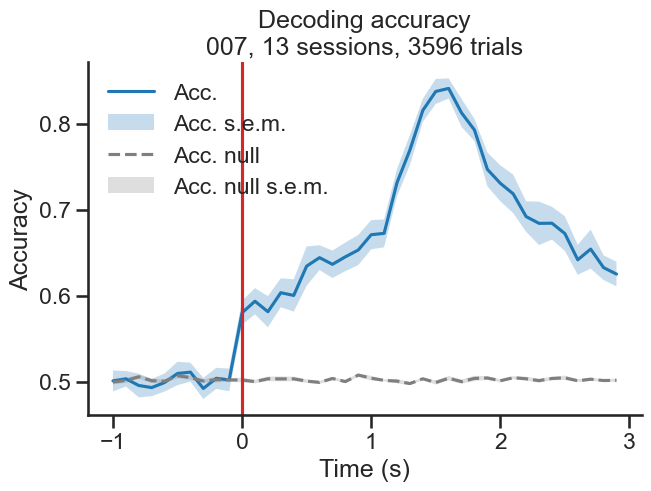

In [31]:
# Plot mean within decoder results across sessions
plot_mean_within_decoder(results, z_null=False)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f"{subject}, {n_sessions} sessions, {n_trials} trials")

# Cross Temporal Decoder (mean)

In [ ]:
%%time
# Run mean cross decoder across sessions
# results = mean_decoder(kind='cross', engagement=1, save=True)

In [33]:
# Load mean cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_cross_decoder.pkl'), 'rb') as f:
    results = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n 007, 13 sessions, 3596 trials')

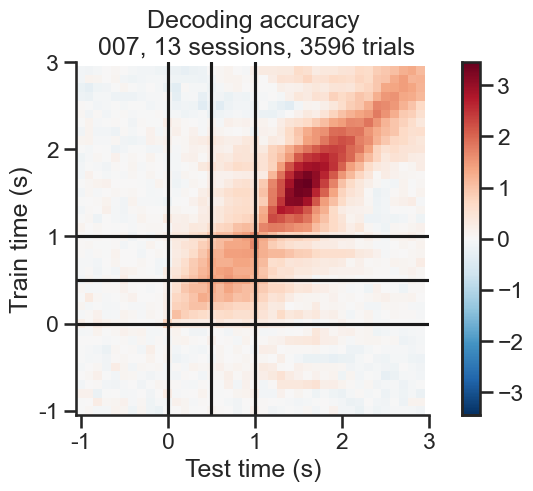

In [36]:
# Plot mean within decoder results across sessions
plot_mean_cross_decoder(results, z_null=True)
n_sessions = len(results['acc'])
n_trials = np.sum([results['acc'][i].shape[0] for i in range(len(results['acc']))])
plt.title(f"Decoding accuracy\n"
          f" {subject}, {n_sessions} sessions, {n_trials} trials")

# Epoch Cross Temporal Decoder (mean)

In [ ]:
%%time
# Run mean epoch cross decoder across sessions
# results_stim = mean_decoder(kind='epoch', epoch='stim', engagement=1, save=True)
# results_delay = mean_decoder(kind='epoch', epoch='delay', engagement=1, save=True)
# results_resp = mean_decoder(kind='epoch', epoch='resp', engagement=1, save=True)

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder took 0.31 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder took 0.31 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder took 0.39 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder took 0.28 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder took 0.36 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder took 0.26 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder took 0.29 seconds to run
Processing session 8/13: 007_2024-06-29_16-24-52...
Disengagement hap

In [6]:
# Load mean epoch cross decoder results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim.pkl'), 'rb') as f:
    results_stim = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay.pkl'), 'rb') as f:
    results_delay = pickle.load(f)
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Decoding accuracy\n007, 13 sessions, 3596 trials')

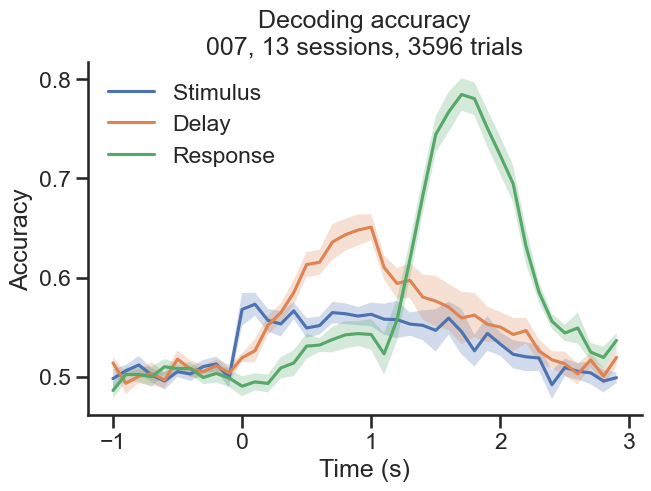

In [7]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim, epoch='stim', z_null=False)
plot_mean_epoch_cross_decoder(results_delay, epoch='delay', z_null=False)
plot_mean_epoch_cross_decoder(results_resp, epoch='resp', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['pred'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Epoch Cross Temporal Decoder Split (mean)

## Stimulus code split by Outcome (blue trace in mean epoch cross temporal decoder)
2 approaches that should lead to the same mean accuracy but **different** null accuracy:
1. Run the epoch cross decoder function above for all trials and then average across trial types according to split (e.g. splitting by outcome in correct/error trials). Mean null  accuracy should be the **same** for each split (flat at 0.5). This is **wrong**
2. Run the epoch cross decoder split function that performs the split when training the decoder. Mean null accuracy should be **different** for each split. This is **correct**

### 1. Run epoch cross decoder function for all trials and average across trial types

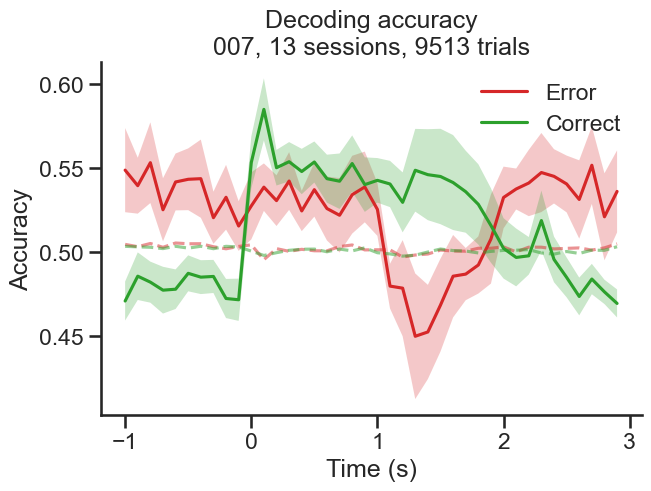

In [15]:
# Split stim decoder into correct vs error trials
# behavior = [behavior[i][behavior[i].Miss==0].reset_index(drop=True) for i in range(len(behavior))]
indexes = [get_trial_indexes(behavior[i], condition='outcome') for i in range(len(behavior))]
# indexes = [get_trial_indexes(behavior[i][behavior[i].Miss==0].reset_index(drop=True), condition='outcome') for i in range(len(behavior))]

# hits = [list(np.where(behavior[i].Hit == True)[0]) for i in range(len(behavior))]
# errors = [list(np.where(behavior[i].Hit == False)[0]) for i in range(len(behavior))]
# misses = [np.where(np.isnan(behavior[i].Hit))[0] for i in range(len(behavior))]
# indexes = [[h, e] for h, e in zip(hits, errors)]

# Error trials
acc_mean_error = [np.nanmean(results_stim['acc'][i][indexes[i][0]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_error = np.array(acc_mean_error)
acc_sem_error = sem(acc_mean_error, axis=0, nan_policy='omit')
acc_mean_error = np.mean(acc_mean_error, axis=0)
acc_null_mean_error = [np.nanmean(results_stim['acc_null'][i][indexes[i][0]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_error = np.array(acc_null_mean_error)
acc_null_mean_error = np.nanmean(acc_null_mean_error, axis=0)

# Correct trials
acc_mean_correct = [np.nanmean(results_stim['acc'][i][indexes[i][1]], axis=0) for i in range(len(results_stim['acc']))]
acc_mean_correct = np.array(acc_mean_correct)
acc_sem_correct = sem(acc_mean_correct, axis=0, nan_policy='omit')
acc_mean_correct = np.nanmean(acc_mean_correct, axis=0)
acc_null_mean_correct = [np.nanmean(results_stim['acc_null'][i][indexes[i][1]], axis=(0, 2)) for i in range(len(results_stim['acc_null']))]
acc_null_mean_correct = np.array(acc_null_mean_correct)
acc_null_mean_correct = np.nanmean(acc_null_mean_correct, axis=0)

plt.figure(constrained_layout=True)

# Error trials
plt.plot(results_stim['bins'][:-1], acc_mean_error, color='tab:red', label='Error')
plt.fill_between(results_stim['bins'][:-1], acc_mean_error - acc_sem_error,
                 acc_mean_error + acc_sem_error, color='tab:red', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_error, color='tab:red', ls='--', alpha=0.5)

# Correct trials
plt.plot(results_stim['bins'][:-1], acc_mean_correct, color='tab:green', label='Correct')
plt.fill_between(results_stim['bins'][:-1], acc_mean_correct - acc_sem_correct,
                 acc_mean_correct + acc_sem_correct, color='tab:green', edgecolor='none',
                 alpha=0.25)
plt.plot(results_stim['bins'][:-1], acc_null_mean_correct, color='tab:green', ls='--', alpha=0.5)

n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Decoding accuracy\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')
plt.xlabel('Time (s)')
plt.ylabel('Accuracy')
plt.legend(frameon=False)
sns.despine()

Note the same mean null accuracy for both splits. This is wrong.

### 2. Run epoch cross decoder split function that performs the split when training the decoder

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim = mean_decoder(kind='epoch_split', epoch='stim', split_by='Hit', engagement=1, save=True)

In [9]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_stim_split_by_Hit.pkl'), 'rb') as f:
    results_stim = pickle.load(f)

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3596 trials')

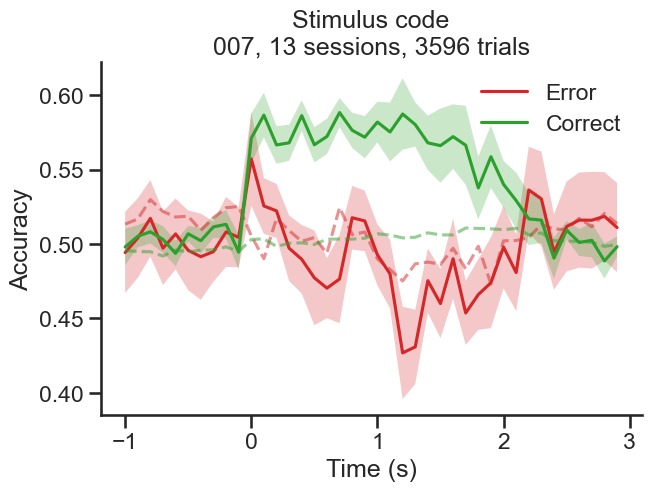

In [10]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_stim, z_null=True)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i][0].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

Note the different mean null accuracy for both splits. This is correct.

Accuracy remains relatively stable around chance (~0.5) before stimulus onset (0s). A transient increase in decoding accuracy around 0s in correct trials, but no strong sustained difference between error and correct trials.
After ~1s, accuracy for correct trials trends slightly higher than for errors, but the separation is modest. For error trials the shuffles closely follow the downward trend of the code because in every error trial the animal licked to the opposite side of stimulus (what I am decoding).
What is more weird is that there's also a lot of code in correct trials's shuffles. It could be a bias.

## Delay code split by Outcome (orange trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay = mean_decoder(kind='epoch_split', epoch='delay', split_by='Hit', engagement=1, save=True)

In [11]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_delay_split_by_Hit.pkl'), 'rb') as f:
    results_delay = pickle.load(f)

Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 3596 trials')

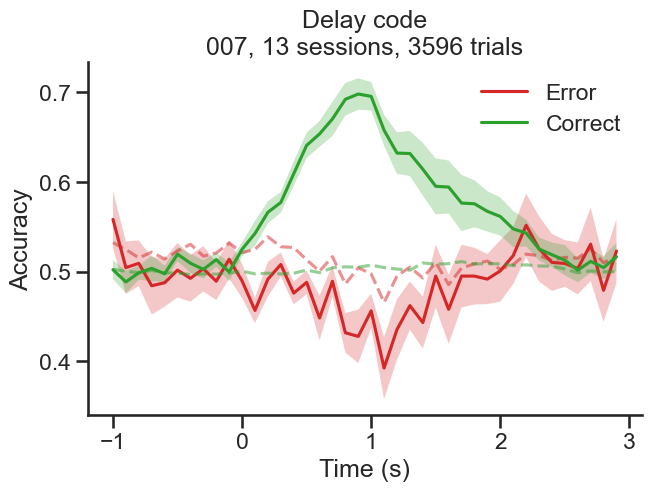

In [12]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_delay, z_null=True)
n_sessions = len(results_delay['acc'])
n_trials = np.sum([results_delay['acc'][i][0].shape[0] for i in range(len(results_delay['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Response code split by Outcome (green trace in mean epoch cross temporal decoder)

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_resp = mean_decoder(kind='epoch_split', epoch='resp', split_by='Hit', engagement=1, save=True)

In [13]:
# Load epoch cross decoder split results across sessions
with open(Path(folder_parent / 'results_mean_epoch_cross_decoder_resp_split_by_Hit.pkl'), 'rb') as f:
    results_resp = pickle.load(f)

Text(0.5, 1.0, 'Response code\n007, 13 sessions, 3596 trials')

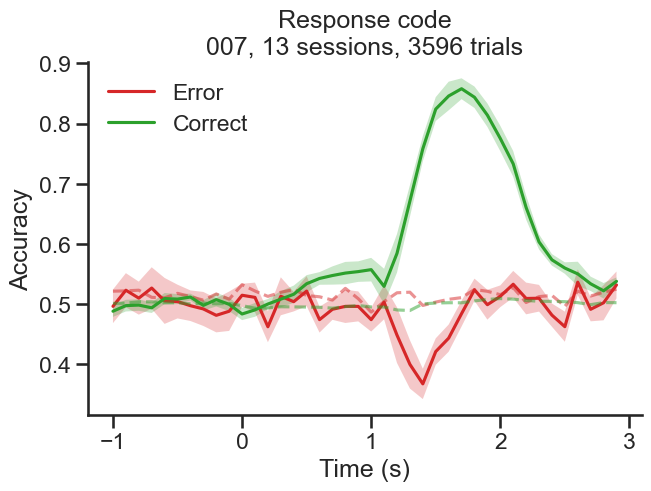

In [14]:
# Plot mean epoch cross decoder split results across sessions
plot_mean_epoch_cross_decoder_split(results_resp, z_null=True)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Engagement

Testing comparison of (stimulus) decoding accuracy of epoch cross decoder between engagement states (engaged vs disengaged)

## Stimulus

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_stim_disengaged = mean_decoder(kind='epoch', epoch='stim', save=False, engagement=0)
# results_stim_engaged = mean_decoder(kind='epoch', epoch='stim', save=False, engagement=1)

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3596 trials')

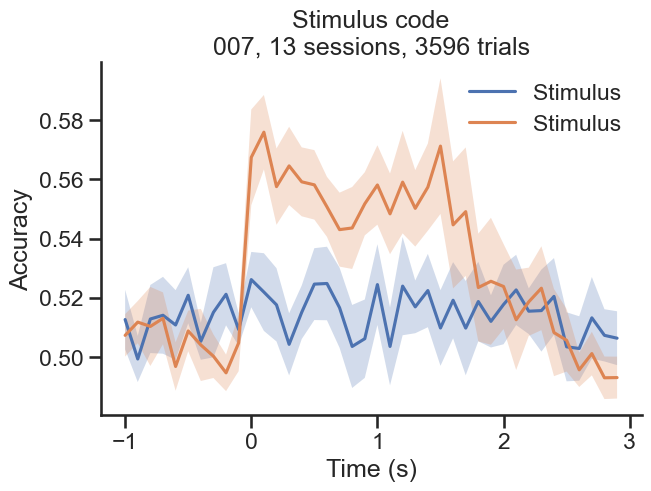

In [27]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_stim_disengaged, epoch='stim', z_null=False)
plot_mean_epoch_cross_decoder(results_stim_engaged, epoch='stim', z_null=False)
n_sessions = len(results_stim['acc'])
n_trials = np.sum([results_stim['acc'][i][0].shape[0] for i in range(len(results_stim['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Delay

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
# results_delay_disengaged = mean_decoder(kind='epoch', epoch='delay', save=False, engagement=0)
# results_delay_engaged = mean_decoder(kind='epoch', epoch='delay', save=False, engagement=1)

Text(0.5, 1.0, 'Delay code\n007, 13 sessions, 3596 trials')

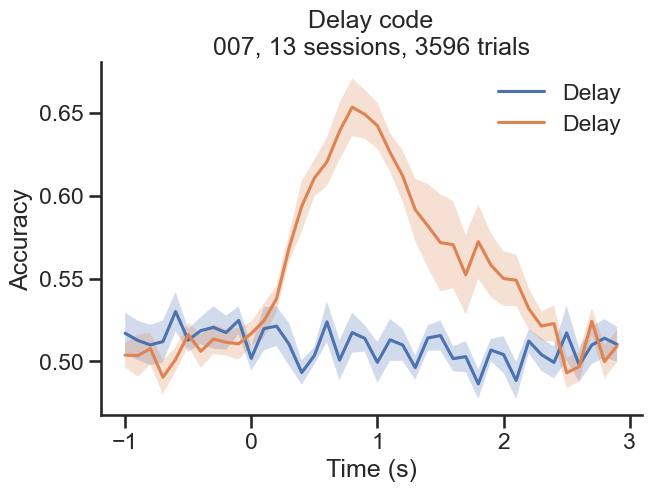

In [22]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_delay_disengaged, epoch='delay', z_null=False)
plot_mean_epoch_cross_decoder(results_delay_engaged, epoch='delay', z_null=False)
n_sessions = len(results_delay['acc'])
n_trials = np.sum([results_delay['acc'][i][0].shape[0] for i in range(len(results_delay['acc']))])
plt.title(f'Delay code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Response

In [ ]:
%%time
# Run mean epoch cross decoder split across sessions
results_resp_disengaged = mean_decoder(kind='epoch', epoch='resp', save=False, engagement=0)
results_resp_engaged = mean_decoder(kind='epoch', epoch='resp', save=False, engagement=1)

Text(0.5, 1.0, 'Response code\n007, 13 sessions, 3596 trials')

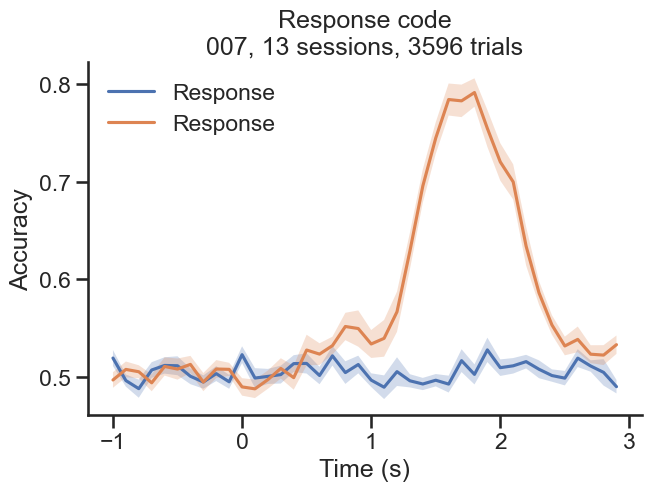

In [28]:
# Plot mean epoch cross decoder results across sessions
plt.figure(constrained_layout=True)
plot_mean_epoch_cross_decoder(results_resp_disengaged, epoch='resp', z_null=False)
plot_mean_epoch_cross_decoder(results_resp_engaged, epoch='resp', z_null=False)
n_sessions = len(results_resp['acc'])
n_trials = np.sum([results_resp['acc'][i][0].shape[0] for i in range(len(results_resp['acc']))])
plt.title(f'Response code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Train in correct trials, test in error trials

### All trials

In [ ]:
results = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=None, save=False)

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3531 trials')

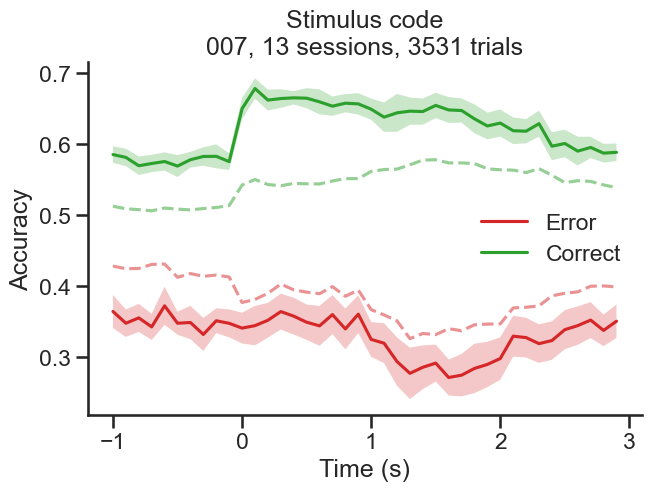

In [43]:
plot_mean_epoch_cross_decoder_split(results, z_null=True)
n_sessions = len(results_engaged['acc'])
n_trials = np.sum([results_engaged['acc'][i][0].shape[0] for i in range(len(results_engaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

### Engaged trials only

In [35]:
results_engaged = mean_decoder(kind='test', epoch='stim', split_by='Hit', engagement=1, save=False)

Processing session 1/13: 007_2024-06-22_10-48-57...
Disengagement happened in trial 222
epoch_cross_decoder_split_TEST took 0.47 seconds to run
Processing session 2/13: 007_2024-06-23_12-46-55...
Disengagement happened in trial 293
epoch_cross_decoder_split_TEST took 0.50 seconds to run
Processing session 3/13: 007_2024-06-24_17-47-22...
Disengagement happened in trial 468
epoch_cross_decoder_split_TEST took 0.60 seconds to run
Processing session 4/13: 007_2024-06-25_15-54-23...
Disengagement happened in trial 240
epoch_cross_decoder_split_TEST took 0.43 seconds to run
Processing session 5/13: 007_2024-06-26_15-19-30...
Disengagement happened in trial 389
epoch_cross_decoder_split_TEST took 0.50 seconds to run
Processing session 6/13: 007_2024-06-27_15-06-28...
Disengagement happened in trial 283
epoch_cross_decoder_split_TEST took 0.42 seconds to run
Processing session 7/13: 007_2024-06-28_14-18-51...
Disengagement happened in trial 239
epoch_cross_decoder_split_TEST took 0.45 seconds

Text(0.5, 1.0, 'Stimulus code\n007, 13 sessions, 3531 trials')

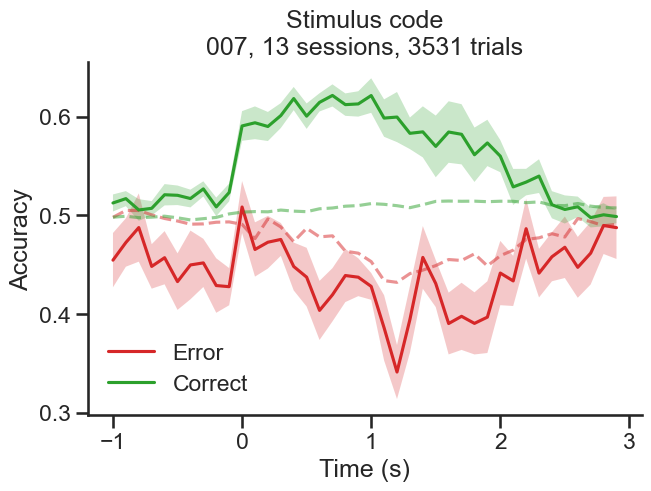

In [44]:
plot_mean_epoch_cross_decoder_split(results_engaged, z_null=True)
n_sessions = len(results_engaged['acc'])
n_trials = np.sum([results_engaged['acc'][i][0].shape[0] for i in range(len(results_engaged['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

## Train in correct engaged trials, test in correct disengaged trials

In [ ]:
def mean_decoder(kind=None, epoch=None, split_by=None, engagement=None, plot=False, save=False):
    """
    Perform within time bin decoder across all sessions.
    :param kind: type of decoder (within, cross, epoch)
    :param save: whether to save the results as a pickle
    :param plot: whether to plot the decoding accuracy for each session
    :return: results (dict)
    """

    results = {
        'pred': [],
        'pred_err': [],
        'acc': [],
        'acc_null': [],
        'bins': []
    }

    for i in range(len(ephys_ids)):

        print(f'Processing session {i + 1}/{len(ephys_ids)}: {ephys_ids[i]}...')

        path_behavior = get_behavior_id(ephys_ids[i])
        df_behavior = parse_v2(path_behavior)
        disengagement = find_disengaged(df_behavior, plot=False)  # Find trial when disengagement happens
        engaged = (df_behavior.Trial <= disengagement).astype(int)  # Compare trials to disengagement (no need for i)
        df_behavior['Engaged'] = engaged
        bins = np.load(folder_parent / ephys_ids[i] / 'bins.npy')
        all_psth = np.load(folder_parent / ephys_ids[i] / 'all_psth.npy')

        if engagement is not None:  # Add engaged column to df_behavior
            if engagement == 0:  # Disengaged trials
                df_behavior = df_behavior[df_behavior.Engaged == 0].reset_index(drop=True)
            elif engagement == 1:  # Engaged trials
                df_behavior = df_behavior[df_behavior.Engaged == 1].reset_index(drop=True)
            all_psth = all_psth[df_behavior.index.values]  # Filter all_psth by selected engagement

        # Misses
        # resp_idx = df_behavior[df_behavior.Miss == 0].index
        resp_idx = df_behavior[df_behavior.Hit == 1].index
        df_behavior = df_behavior.iloc[resp_idx].reset_index(drop=True)
        all_psth = all_psth[resp_idx]
        # split = df_behavior[split_by]

        if kind == 'within':
            pred, pred_err, acc, acc_null = within_decoder(all_psth, df_behavior.Side)
            filename = 'results_mean_within_decoder.pkl'
        elif kind == 'cross':
            pred, pred_err, acc, acc_null = cross_decoder(all_psth, df_behavior.Side)
            filename = 'results_mean_cross_decoder.pkl'
        elif kind == 'epoch':
            pred, pred_err, acc, acc_null = epoch_cross_decoder(bins, epoch, all_psth, df_behavior.Side)
            filename = 'results_mean_epoch_cross_decoder' + '_' + epoch + '.pkl'
        elif kind == 'epoch_split':
            split = df_behavior[split_by]
            pred, pred_err, acc, acc_null = epoch_cross_decoder_split(bins, split, epoch=epoch, X=all_psth,
                                                                      y=df_behavior.Side)
            filename = 'results_mean_epoch_cross_decoder' + '_' + epoch + '_' + 'split_by' + '_' + split_by + '.pkl'
        elif kind == 'test':
            split = df_behavior[split_by]
            pred, pred_err, acc, acc_null = epoch_cross_decoder_split_TEST(bins, split, epoch='stim',
                                                                           X=all_psth, y=df_behavior.Side,
                                                                           n_shuffles=100)
            filename = 'results_mean_TEST.pkl'

        results['pred'].append(pred)
        results['pred_err'].append(pred_err)
        results['acc'].append(acc)
        results['acc_null'].append(acc_null)
        results['bins'] = bins

    # Plot decoding accuracy for each session
    if plot:
        if kind == 'within':
            plot_within_decoder(bins, results['acc'][i], results['acc_null'][i], z_null=True)
        elif kind == 'cross':
            plot_cross_decoder(bins, acc, acc_null, z_null=True)
        elif kind == 'epoch':
            pass
        elif kind == 'epoch_split':
            pass

    if save:
        os.chdir(folder_parent)
        with open(filename, 'wb') as f:
            pickle.dump(results, f)

    return results

In [ ]:
results_correct = mean_decoder(kind='test', epoch='stim', split_by='Engaged', engagement=None, save=False)

Text(0.5, 1.0, 'Stimulus code\n007, 12 sessions, 5366 trials')

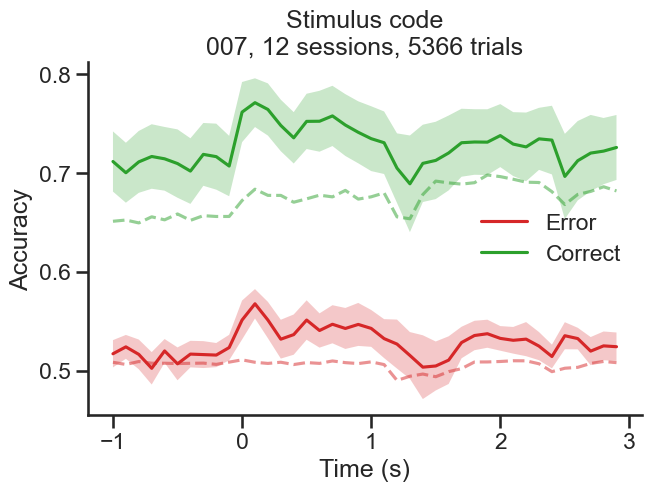

In [53]:
plot_mean_epoch_cross_decoder_split(results_correct, z_null=True)
n_sessions = len(results_correct['acc'])
n_trials = np.sum([results_correct['acc'][i][0].shape[0] for i in range(len(results_correct['acc']))])
plt.title(f'Stimulus code\n'
          f'{subject}, {n_sessions} sessions, {n_trials} trials')

# Population selectivity analysis

From:
Inagaki, H. K., Chen, S., Ridder, M. C., Sah, P., Li, N., Yang, Z., Hasanbegovic, H., Gao, Z., Gerfen, C. R., & Svoboda, K. (2022). A midbrain-thalamus-cortex circuit reorganizes cortical dynamics to initiate movement. Cell, 185(6), 1065-1081.e23. https://doi.org/10.1016/j.cell.2022.02.006

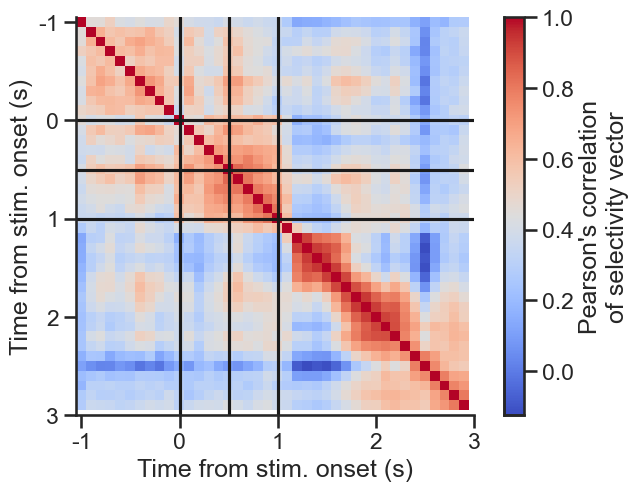

In [36]:
# Align to stimulus onset
df_behavior = behavior[0]
bins = np.load(folder_parent / ephys_ids[0] / 'bins.npy')
all_psth = np.load(folder_parent / ephys_ids[0] / 'all_psth.npy')

# Step 1: Separate trials by condition
left_lick_trials = df_behavior[df_behavior.Choice == 0].Trial
right_lick_trials = df_behavior[df_behavior.Choice == 1].Trial

# Step 2: Compute mean firing rates per time bin
r_lick_left = np.mean(all_psth[left_lick_trials], axis=0)  # shape (bins, neurons)
r_lick_right = np.mean(all_psth[right_lick_trials], axis=0)  # shape (bins, neurons)

# Step 3: Compute selectivity vector w_t
wt = r_lick_right - r_lick_left  # shape (bins, neurons)

# Step 4: Perform SVD to get the dominant coding direction
U, S, Vt = np.linalg.svd(wt, full_matrices=False)

# Step 5: CD_delay is the first right singular vector (principal axis)
CD_delay = Vt[0, :]  # First singular vector (neurons,)

# Step 6: Normalize to unit vector
CD_delay /= np.linalg.norm(CD_delay)

# Step 7: Compute correlation matrix
corr_matrix = np.corrcoef(wt)
# np.fill_diagonal(corr_matrix, np.nan)  # Remove diagonal by setting it to NaN

# Step 8: Plot correlation matrix
plt.figure(constrained_layout=True)
plt.imshow(corr_matrix, cmap='coolwarm', origin='lower')
plt.axhline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axvline(np.where(bins == 0)[0], color='k', linestyle='-')  # Stimulus onset
plt.axhline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axvline(np.where(bins == 0.5)[0], color='k', linestyle='-')  # Delay
plt.axhline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.axvline(np.where(bins == 1)[0], color='k', linestyle='-')  # Go cue
plt.xticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.yticks(np.arange(0, len(bins), 10), np.round(bins[::10]).astype(int))
plt.colorbar(label="Pearson's correlation\nof selectivity vector")
plt.xlabel('Time from stim. onset (s)')
plt.ylabel('Time from stim. onset (s)')
# plt.title('Correlation of Population Selectivity Over Time')
sns.despine()

Pearson's correlation is high during the delay epoch (0.5-1 s), meaning that a similar subpopulation of neurons holds selectivity during motor planning. In contrast, population selectivity show a low correlation before and after the Go cue (1 s), meaning that different subpopulations of neurons show selectivity. Population activity patterns in M2 change rapidly before and during movement initiation.